In [ ]:
import torch
import zipfile
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score, average_precision_score

print("cuda available:", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

cuda available: True
device: Tesla T4


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import zipfile
import shutil

ROOT = Path("/content/drive/MyDrive/ADS2002")
ZIP_PATH = ROOT / "sample_images.zip"

LOCAL_DATA = Path("/content/data")

print("ZIP exists:", ZIP_PATH.exists())

# Clean old temporary extraction if needed
shutil.rmtree(LOCAL_DATA / "sample_images", ignore_errors=True)

# Extract ZIP to local Colab storage
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(LOCAL_DATA)

# Find all JPGs
jpgs = list(LOCAL_DATA.rglob("*.jpg"))

print("Total JPGs found:", len(jpgs))
print("Example:", jpgs[0] if jpgs else "No images found")

ZIP exists: True
Total JPGs found: 8852
Example: /content/data/sample_images/sample_images/ISIC_4253846.jpg


In [ ]:
ROOT = Path("/content/drive/MyDrive/ADS2002")

SPLIT_DIR = ROOT / "splits(FINAL)"
OUT_DIR = ROOT / "outputs"
IMAGE_DIR = Path("/content/data/sample_images/sample_images")

OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load split CSVs
train_df = pd.read_csv(SPLIT_DIR / "train_labels.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_labels.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_labels.csv")

print("CUDA:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("IMAGE_DIR:", IMAGE_DIR)
print("Local JPG count:", len(list(IMAGE_DIR.glob("*.jpg"))))

CUDA: True Tesla T4
Train: 5598
Validation: 1266
Test: 1988
IMAGE_DIR: /content/data/sample_images/sample_images
Local JPG count: 8852


In [ ]:
local = Path("/content/data")
print("exists:", local.exists())
print("tree:")
for p in local.rglob("*"):
    if p.is_dir():
        n_jpg = len(list(p.glob("*.jpg")))
        print(" DIR ", p, "jpg in this folder:", n_jpg)
    elif p.suffix.lower() in {".jpg", ".jpeg"}:
        pass

jpgs = list(local.rglob("*.jpg")) + list(local.rglob("*.jpeg")) + list(local.rglob("*.JPG"))
print("jpg anywhere under /content/data:", len(jpgs))
if jpgs:
    print("example:", jpgs[0])

exists: True
tree:
 DIR  /content/data/sample_images jpg in this folder: 0
 DIR  /content/data/sample_images/sample_images jpg in this folder: 8852
jpg anywhere under /content/data: 8852
example: /content/data/sample_images/sample_images/ISIC_4253846.jpg


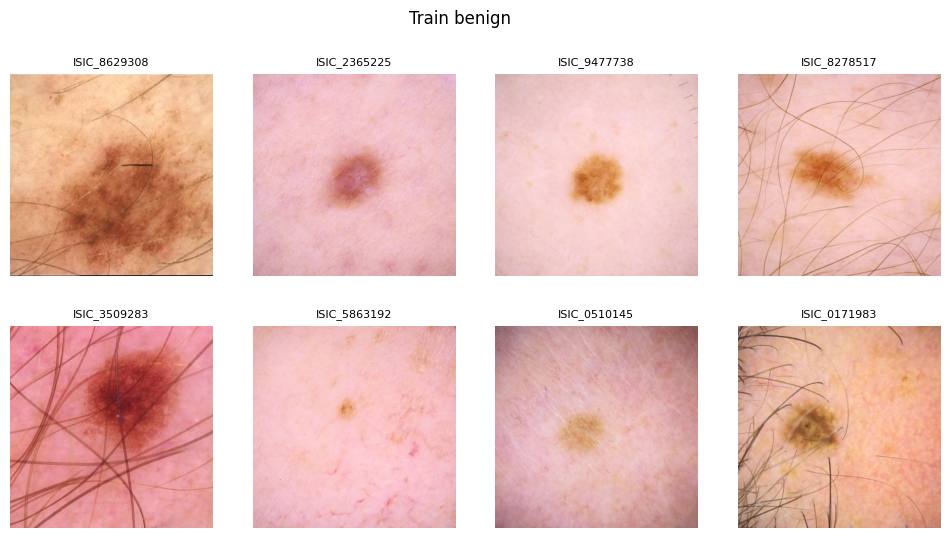

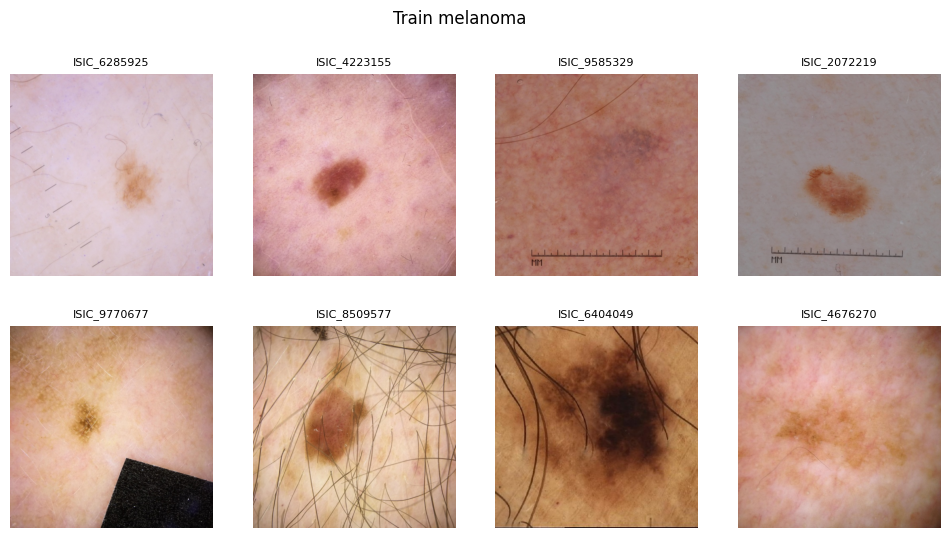

target
0    5499
1      99
Name: count, dtype: int64


In [ ]:
def show_examples(df, target, n=8, title=""):
    subset = df[df["target"] == target]
    names = subset["image_name"].sample(n=min(n, len(subset)), random_state=42)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, name in zip(axes.ravel(), names):
        img = Image.open(IMAGE_DIR / f"{name}.jpg").convert("RGB")
        ax.imshow(img)
        ax.set_title(name, fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.show()

show_examples(train_df, 0, title="Train benign")
show_examples(train_df, 1, title="Train melanoma")
print(train_df["target"].value_counts())

In [ ]:
# set the standard Image-Net1K channel means & standard deviations
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.1, 0.1, 0.1, 0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),])

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),])

class MelanomaDataset(Dataset):
    def __init__(self, df, image_dir, transform):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.image_dir / f"{row['image_name']}.jpg").convert("RGB")
        x = self.transform(img)
        y = torch.tensor(row["target"], dtype=torch.float32)
        return x, y

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader = DataLoader(
    MelanomaDataset(train_df, IMAGE_DIR, train_tf),
    batch_size=32, shuffle=True, num_workers=0,
)

val_loader = DataLoader(
    MelanomaDataset(val_df, IMAGE_DIR, eval_tf),
    batch_size=32, shuffle=False, num_workers=0,
)

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape, yb.mean().item())

torch.Size([32, 3, 224, 224]) torch.Size([32]) 0.0


## Experiment 1 - DenseNet121 Baseline

- Uses a pretrained DenseNet121 for binary melanoma classification.
- The pretrained feature extractor is frozen.
- Only the final classifier is trained.
- Uses the same train/validation split, augmentation, class weighting and evaluation metrics as the ResNet18 baseline.
- This allows a fair comparison between different pretrained CNN architectures.

In [ ]:
# DenseNet121 baseline

model = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze pretrained feature extractor
for p in model.parameters():
    p.requires_grad = False

# Replace the final classifier
model.classifier = nn.Linear(
    model.classifier.in_features,
    1
)

model.classifier.requires_grad_(True)

model = model.to(device)


# Class imbalance weighting
n_pos = int(train_df["target"].sum())
n_neg = len(train_df) - n_pos

pos_weight = torch.tensor(
    [n_neg / n_pos],
    device=device
)

print("pos_weight:", float(pos_weight))

loss_fn = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)


def run_epoch(loader, train=True):

    model.train(train)

    total = 0.0
    ys = []
    ps = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):

            logit = model(x).squeeze(1)

            loss = loss_fn(logit, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total += loss.item() * len(y)

        ys.append(
            y.detach().cpu().numpy()
        )

        ps.append(
            torch.sigmoid(logit)
            .detach()
            .cpu()
            .numpy()
        )

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)

    return (
        total / len(loader.dataset),
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        y_true,
        y_prob
    )


history = []

for epoch in range(1, 6):

    tr = run_epoch(
        train_loader,
        True
    )

    va = run_epoch(
        val_loader,
        False
    )

    history.append((tr, va))

    print(
        f"epoch {epoch}  "
        f"train loss {tr[0]:.4f} "
        f"auc {tr[1]:.3f} "
        f"ap {tr[2]:.3f} | "
        f"val loss {va[0]:.4f} "
        f"auc {va[1]:.3f} "
        f"ap {va[2]:.3f}"
    )

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 99.0MB/s]


pos_weight: 55.54545593261719
epoch 1  train loss 1.3112 auc 0.629 ap 0.036 | val loss 1.2714 auc 0.805 ap 0.125


KeyboardInterrupt: 

### DenseNet121 Baseline Result

The frozen DenseNet121 baseline achieved a best validation ROC-AUC of approximately 0.842 and a best PR-AUC of approximately 0.151.

The model showed useful predictive ability, although its ROC-AUC was lower than the best partially fine-tuned ResNet18 result. PR-AUC continued to improve across epochs, suggesting DenseNet121 may benefit from further fine-tuning.

## Experiment 2 – Partial Fine-Tuning

This experiment tests whether allowing the later DenseNet121 layers to adapt to the melanoma images improves validation performance.

Compared with the baseline:
- The earlier DenseNet layers remain frozen.
- The final dense block and classifier are trainable.
- A smaller learning rate is used for fine-tuning.
- The same augmentation, class weighting and validation metrics are retained.

In [ ]:
# DenseNet121 Experiment 2: Partial fine-tuning

model_ft = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze all parameters first
for p in model_ft.parameters():
    p.requires_grad = False

# Unfreeze the last dense block
for p in model_ft.features.denseblock4.parameters():
    p.requires_grad = True

# Also unfreeze the final normalization layer
for p in model_ft.features.norm5.parameters():
    p.requires_grad = True

# Replace final classifier
model_ft.classifier = nn.Linear(
    model_ft.classifier.in_features,
    1
)

model_ft.classifier.requires_grad_(True)

model_ft = model_ft.to(device)


# Same class weighting
n_pos = int(train_df["target"].sum())
n_neg = len(train_df) - n_pos

pos_weight_ft = torch.tensor(
    [n_neg / n_pos],
    device=device
)

loss_fn_ft = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_ft
)


# Smaller learning rate for fine-tuning
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)


def run_epoch_ft(loader, train=True):

    model_ft.train(train)

    total = 0.0
    ys = []
    ps = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):

            logit = model_ft(x).squeeze(1)

            loss = loss_fn_ft(logit, y)

            if train:
                optimizer_ft.zero_grad()
                loss.backward()
                optimizer_ft.step()

        total += loss.item() * len(y)

        ys.append(
            y.detach().cpu().numpy()
        )

        ps.append(
            torch.sigmoid(logit)
            .detach()
            .cpu()
            .numpy()
        )

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)

    return (
        total / len(loader.dataset),
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        y_true,
        y_prob
    )


history_ft = []

for epoch in range(1, 6):

    tr = run_epoch_ft(
        train_loader,
        True
    )

    va = run_epoch_ft(
        val_loader,
        False
    )

    history_ft.append((tr, va))

    print(
        f"epoch {epoch}  "
        f"train loss {tr[0]:.4f} "
        f"auc {tr[1]:.3f} "
        f"ap {tr[2]:.3f} | "
        f"val loss {va[0]:.4f} "
        f"auc {va[1]:.3f} "
        f"ap {va[2]:.3f}"
    )

### DenseNet121 Experiment 2 Result

Partial fine-tuning substantially improved DenseNet121 compared with the frozen baseline.

The model achieved a validation ROC-AUC of 0.894 and PR-AUC of 0.206 at Epoch 4. Although ROC-AUC increased slightly to 0.900 at Epoch 5, PR-AUC decreased to 0.185.

Overall, fine-tuning the later DenseNet121 layers helped the model adapt better to the melanoma images, especially in identifying the rare positive class.

## Experiment 3 – Stronger Augmentation + Partial Fine-Tuning

This experiment keeps the partial fine-tuning setup from Experiment 2, but applies stronger image augmentation during training.

Compared with Experiment 2:
- Rotation is increased.
- Stronger colour jitter is applied.
- Small translation and scaling are added.
- The same DenseNet121 fine-tuning strategy, class weighting, learning rate and validation metrics are used.

In [ ]:
# DenseNet121 Experiment 3:
# Stronger augmentation + partial fine-tuning

# Stronger augmentation
train_tf_strong = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# New training loader using stronger augmentation
train_loader_exp3 = DataLoader(
    MelanomaDataset(
        train_df,
        IMAGE_DIR,
        train_tf_strong
    ),
    batch_size=32,
    shuffle=True,
    num_workers=0
)

# Validation stays unchanged
val_loader_exp3 = DataLoader(
    MelanomaDataset(
        val_df,
        IMAGE_DIR,
        eval_tf
    ),
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# Fresh pretrained DenseNet121
model_exp3 = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze everything first
for p in model_exp3.parameters():
    p.requires_grad = False

# Unfreeze the final DenseNet block
for p in model_exp3.features.denseblock4.parameters():
    p.requires_grad = True

# Unfreeze final normalization layer
for p in model_exp3.features.norm5.parameters():
    p.requires_grad = True

# Replace classifier for binary classification
model_exp3.classifier = nn.Linear(
    model_exp3.classifier.in_features,
    1
)

model_exp3.classifier.requires_grad_(True)

model_exp3 = model_exp3.to(device)


# Same class imbalance weighting
n_pos = int(train_df["target"].sum())
n_neg = len(train_df) - n_pos

pos_weight_exp3 = torch.tensor(
    [n_neg / n_pos],
    device=device
)

loss_fn_exp3 = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_exp3
)


# Same learning rate as Experiment 2
optimizer_exp3 = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_exp3.parameters()
    ),
    lr=1e-4
)


# Training / validation function
def run_epoch_exp3(loader, train=True):

    model_exp3.train(train)

    total = 0.0
    ys = []
    ps = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):

            logit = model_exp3(x).squeeze(1)

            loss = loss_fn_exp3(logit, y)

            if train:
                optimizer_exp3.zero_grad()
                loss.backward()
                optimizer_exp3.step()

        total += loss.item() * len(y)

        ys.append(
            y.detach().cpu().numpy()
        )

        ps.append(
            torch.sigmoid(logit)
            .detach()
            .cpu()
            .numpy()
        )

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)

    return (
        total / len(loader.dataset),
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        y_true,
        y_prob
    )


# Train for 5 epochs
history_exp3 = []

for epoch in range(1, 6):

    tr = run_epoch_exp3(
        train_loader_exp3,
        True
    )

    va = run_epoch_exp3(
        val_loader_exp3,
        False
    )

    history_exp3.append((tr, va))

    print(
        f"epoch {epoch}  "
        f"train loss {tr[0]:.4f} "
        f"auc {tr[1]:.3f} "
        f"ap {tr[2]:.3f} | "
        f"val loss {va[0]:.4f} "
        f"auc {va[1]:.3f} "
        f"ap {va[2]:.3f}"
    )

### DenseNet121 Experiment 3 Result

Stronger augmentation combined with partial fine-tuning achieved the best DenseNet121 performance so far.

The best result occurred at Epoch 3, with a validation ROC-AUC of 0.931 and PR-AUC of 0.282.

Compared with the frozen baseline and partial fine-tuning alone, this suggests that stronger augmentation helped the fine-tuned DenseNet121 generalise better to unseen validation images.

Performance decreased after Epoch 3, suggesting that further training did not provide additional benefit.

## DenseNet121 Experiment Comparison

| Experiment | Setup | Best Val ROC-AUC | Best Val PR-AUC |
|---|---|---:|---:|
| Experiment 1 | Frozen DenseNet121 baseline | 0.842 | 0.151 |
| Experiment 2 | Partial fine-tuning | 0.900 | 0.206 |
| Experiment 3 | Partial fine-tuning + stronger augmentation | **0.931** | **0.282** |

### Overall Findings

The DenseNet121 experiments show a clear improvement as the training strategy was refined.

- **Experiment 1:** The frozen pretrained DenseNet121 provided a reasonable baseline, showing that pretrained image features were already useful for melanoma classification.
- **Experiment 2:** Partial fine-tuning improved performance, suggesting that allowing the later DenseNet layers to adapt to dermoscopic images helped the model learn more task-specific features.
- **Experiment 3:** Combining partial fine-tuning with stronger augmentation produced the best validation performance, achieving a ROC-AUC of **0.931** and PR-AUC of **0.282** at Epoch 3.

Overall, the results suggest that both **fine-tuning and data augmentation are important for improving DenseNet121 performance** on this highly imbalanced melanoma dataset.

Experiment 3 is therefore the strongest DenseNet121 configuration tested so far.

## **Comparison of Image Models**

Three pretrained CNN architectures were explored for melanoma image classification: ResNet18, DenseNet121 and EfficientNet-B0.

| Model | Main approach | Validation ROC-AUC | Validation PR-AUC |
|---|---|---:|---:|
| ResNet18 | Pretrained ResNet18 baseline with class weighting and image augmentation | ~0.85 | ~0.13 |
| EfficientNet-B0 | Pretrained EfficientNet-B0 with fine-tuning | ~0.87 | ~0.21 |
| **DenseNet121** | Partial fine-tuning + stronger augmentation | **0.931** | **0.282** |

### Comparison

All three pretrained CNN models were able to learn useful information from the dermoscopic images.

ResNet18 provided a useful baseline, while EfficientNet-B0 achieved stronger validation performance after fine-tuning.

DenseNet121 achieved the strongest validation results among the three approaches tested, reaching a ROC-AUC of **0.931** and PR-AUC of **0.282**. The improvement was obtained after partially fine-tuning the network and applying stronger data augmentation.

These results suggest that both the CNN architecture and the training strategy can affect melanoma classification performance. In particular, allowing pretrained features to adapt to the dermoscopic images and using suitable augmentation improved the DenseNet121 model.

However, the models were not trained using completely identical optimisation procedures, so the results should be treated as an initial comparison rather than a strict architecture-only comparison.

# Reproducible DenseNet121 Experiments (Seed = 42)

The previous DenseNet121 experiments were exploratory and did not use a fixed random seed.

Because model initialization, batch shuffling and image augmentation contain random elements, repeated training runs may produce different results.

The following experiments repeat the DenseNet121 analysis using a fixed seed of 42 to improve reproducibility and provide a fairer comparison between configurations.

In [ ]:
# ============================================================
# Reproducibility setup
# ============================================================

import random
import numpy as np
import torch

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More reproducible CUDA behaviour
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


## Seeded Experiment 1 – Frozen DenseNet121 Baseline

This repeats the original DenseNet121 baseline using a fixed random seed.

- Pretrained DenseNet121
- Feature extractor frozen
- Only the final classifier is trained
- Standard augmentation
- Class-weighted BCE loss
- Seed = 42

In [ ]:
# ============================================================
# SEEDED EXPERIMENT 1
# Frozen DenseNet121 baseline
# ============================================================

set_seed(SEED)

# Create a seeded generator for DataLoader shuffling
g1 = torch.Generator()
g1.manual_seed(SEED)

train_loader_s1 = DataLoader(
    MelanomaDataset(
        train_df,
        IMAGE_DIR,
        train_tf
    ),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=g1
)

val_loader_s1 = DataLoader(
    MelanomaDataset(
        val_df,
        IMAGE_DIR,
        eval_tf
    ),
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# Fresh DenseNet121
model_s1 = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze all pretrained parameters
for p in model_s1.parameters():
    p.requires_grad = False

# Replace final classifier
model_s1.classifier = nn.Linear(
    model_s1.classifier.in_features,
    1
)

model_s1.classifier.requires_grad_(True)

model_s1 = model_s1.to(device)


# Class weighting
n_pos = int(train_df["target"].sum())
n_neg = len(train_df) - n_pos

pos_weight_s1 = torch.tensor(
    [n_neg / n_pos],
    device=device
)

loss_fn_s1 = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_s1
)

optimizer_s1 = torch.optim.Adam(
    model_s1.classifier.parameters(),
    lr=1e-3
)


def run_epoch_s1(loader, train=True):

    model_s1.train(train)

    total = 0.0
    ys = []
    ps = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):

            logit = model_s1(x).squeeze(1)
            loss = loss_fn_s1(logit, y)

            if train:
                optimizer_s1.zero_grad()
                loss.backward()
                optimizer_s1.step()

        total += loss.item() * len(y)

        ys.append(
            y.detach().cpu().numpy()
        )

        ps.append(
            torch.sigmoid(logit)
            .detach()
            .cpu()
            .numpy()
        )

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)

    return (
        total / len(loader.dataset),
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        y_true,
        y_prob
    )


history_s1 = []

for epoch in range(1, 6):

    tr = run_epoch_s1(
        train_loader_s1,
        True
    )

    va = run_epoch_s1(
        val_loader_s1,
        False
    )

    history_s1.append((tr, va))

    print(
        f"epoch {epoch}  "
        f"train loss {tr[0]:.4f} "
        f"auc {tr[1]:.3f} "
        f"ap {tr[2]:.3f} | "
        f"val loss {va[0]:.4f} "
        f"auc {va[1]:.3f} "
        f"ap {va[2]:.3f}"
    )

epoch 1  train loss 1.2460 auc 0.691 ap 0.035 | val loss 1.5228 auc 0.818 ap 0.094
epoch 2  train loss 1.1197 auc 0.770 ap 0.068 | val loss 1.1858 auc 0.861 ap 0.141
epoch 3  train loss 1.0812 auc 0.791 ap 0.079 | val loss 1.1943 auc 0.860 ap 0.144
epoch 4  train loss 0.9818 auc 0.836 ap 0.088 | val loss 1.1094 auc 0.857 ap 0.152
epoch 5  train loss 0.9738 auc 0.837 ap 0.080 | val loss 1.0516 auc 0.866 ap 0.181


## Seeded Experiment 2 – Partial Fine-Tuning

This experiment keeps the same seed and preprocessing, but allows the final DenseNet block to adapt to the melanoma images.

- `denseblock4` is trainable
- `norm5` is trainable
- Final classifier is trainable
- Learning rate reduced to `1e-4`
- Seed = 42

In [ ]:
# ============================================================
# SEEDED EXPERIMENT 2
# Partial fine-tuning
# ============================================================

set_seed(SEED)

g2 = torch.Generator()
g2.manual_seed(SEED)

train_loader_s2 = DataLoader(
    MelanomaDataset(
        train_df,
        IMAGE_DIR,
        train_tf
    ),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=g2
)

val_loader_s2 = DataLoader(
    MelanomaDataset(
        val_df,
        IMAGE_DIR,
        eval_tf
    ),
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# Fresh DenseNet121
model_s2 = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze everything first
for p in model_s2.parameters():
    p.requires_grad = False

# Unfreeze last dense block
for p in model_s2.features.denseblock4.parameters():
    p.requires_grad = True

# Unfreeze final normalization
for p in model_s2.features.norm5.parameters():
    p.requires_grad = True

# Replace classifier
model_s2.classifier = nn.Linear(
    model_s2.classifier.in_features,
    1
)

model_s2.classifier.requires_grad_(True)

model_s2 = model_s2.to(device)


# Same class weighting
pos_weight_s2 = torch.tensor(
    [n_neg / n_pos],
    device=device
)

loss_fn_s2 = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_s2
)

optimizer_s2 = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_s2.parameters()
    ),
    lr=1e-4
)


def run_epoch_s2(loader, train=True):

    model_s2.train(train)

    total = 0.0
    ys = []
    ps = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):

            logit = model_s2(x).squeeze(1)
            loss = loss_fn_s2(logit, y)

            if train:
                optimizer_s2.zero_grad()
                loss.backward()
                optimizer_s2.step()

        total += loss.item() * len(y)

        ys.append(
            y.detach().cpu().numpy()
        )

        ps.append(
            torch.sigmoid(logit)
            .detach()
            .cpu()
            .numpy()
        )

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)

    return (
        total / len(loader.dataset),
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        y_true,
        y_prob
    )


history_s2 = []

for epoch in range(1, 6):

    tr = run_epoch_s2(
        train_loader_s2,
        True
    )

    va = run_epoch_s2(
        val_loader_s2,
        False
    )

    history_s2.append((tr, va))

    print(
        f"epoch {epoch}  "
        f"train loss {tr[0]:.4f} "
        f"auc {tr[1]:.3f} "
        f"ap {tr[2]:.3f} | "
        f"val loss {va[0]:.4f} "
        f"auc {va[1]:.3f} "
        f"ap {va[2]:.3f}"
    )

epoch 1  train loss 1.1585 auc 0.746 ap 0.057 | val loss 1.1481 auc 0.886 ap 0.187
epoch 2  train loss 0.9120 auc 0.862 ap 0.132 | val loss 0.9285 auc 0.913 ap 0.218
epoch 3  train loss 0.8331 auc 0.886 ap 0.180 | val loss 0.8173 auc 0.925 ap 0.196
epoch 4  train loss 0.7443 auc 0.909 ap 0.257 | val loss 0.8043 auc 0.924 ap 0.207
epoch 5  train loss 0.6138 auc 0.942 ap 0.289 | val loss 0.7960 auc 0.914 ap 0.144


## Seeded Experiment 3 – Partial Fine-Tuning + Stronger Augmentation

This experiment combines partial fine-tuning with stronger image augmentation.

Compared with Experiment 2:

- Rotation increased to 30°
- Stronger colour jitter
- Small translation and scaling
- Same fine-tuning strategy
- Same learning rate
- Same seed = 42

In [ ]:
# ============================================================
# SEEDED EXPERIMENT 3
# Stronger augmentation + partial fine-tuning
# ============================================================

set_seed(SEED)


# Stronger augmentation
train_tf_strong_seed = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    ),
])


g3 = torch.Generator()
g3.manual_seed(SEED)

train_loader_s3 = DataLoader(
    MelanomaDataset(
        train_df,
        IMAGE_DIR,
        train_tf_strong_seed
    ),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=g3
)

val_loader_s3 = DataLoader(
    MelanomaDataset(
        val_df,
        IMAGE_DIR,
        eval_tf
    ),
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# Fresh DenseNet121
model_s3 = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze everything
for p in model_s3.parameters():
    p.requires_grad = False

# Unfreeze final dense block
for p in model_s3.features.denseblock4.parameters():
    p.requires_grad = True

# Unfreeze final normalization
for p in model_s3.features.norm5.parameters():
    p.requires_grad = True

# Replace classifier
model_s3.classifier = nn.Linear(
    model_s3.classifier.in_features,
    1
)

model_s3.classifier.requires_grad_(True)

model_s3 = model_s3.to(device)


# Same class weighting
pos_weight_s3 = torch.tensor(
    [n_neg / n_pos],
    device=device
)

loss_fn_s3 = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_s3
)

optimizer_s3 = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_s3.parameters()
    ),
    lr=1e-4
)


def run_epoch_s3(loader, train=True):

    model_s3.train(train)

    total = 0.0
    ys = []
    ps = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):

            logit = model_s3(x).squeeze(1)
            loss = loss_fn_s3(logit, y)

            if train:
                optimizer_s3.zero_grad()
                loss.backward()
                optimizer_s3.step()

        total += loss.item() * len(y)

        ys.append(
            y.detach().cpu().numpy()
        )

        ps.append(
            torch.sigmoid(logit)
            .detach()
            .cpu()
            .numpy()
        )

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)

    return (
        total / len(loader.dataset),
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        y_true,
        y_prob
    )


history_s3 = []

for epoch in range(1, 6):

    tr = run_epoch_s3(
        train_loader_s3,
        True
    )

    va = run_epoch_s3(
        val_loader_s3,
        False
    )

    history_s3.append((tr, va))

    print(
        f"epoch {epoch}  "
        f"train loss {tr[0]:.4f} "
        f"auc {tr[1]:.3f} "
        f"ap {tr[2]:.3f} | "
        f"val loss {va[0]:.4f} "
        f"auc {va[1]:.3f} "
        f"ap {va[2]:.3f}"
    )

epoch 1  train loss 1.1841 auc 0.735 ap 0.049 | val loss 1.0629 auc 0.871 ap 0.161
epoch 2  train loss 1.0504 auc 0.806 ap 0.082 | val loss 0.9752 auc 0.889 ap 0.187
epoch 3  train loss 0.8785 auc 0.872 ap 0.135 | val loss 0.8528 auc 0.914 ap 0.197
epoch 4  train loss 0.7779 auc 0.900 ap 0.170 | val loss 0.8414 auc 0.910 ap 0.236
epoch 5  train loss 0.7407 auc 0.908 ap 0.171 | val loss 0.9309 auc 0.888 ap 0.172


## Seeded DenseNet121 Comparison

All experiments below use a fixed random seed of 42 to improve reproducibility.

| Experiment | Configuration | Val ROC-AUC | Val PR-AUC |
|---|---|---:|---:|
| Seeded Exp 1 | Frozen DenseNet121 baseline | 0.866 | 0.181 |
| Seeded Exp 2 | Partial fine-tuning | **0.913** | 0.218 |
| Seeded Exp 3 | Partial fine-tuning + stronger augmentation | 0.910 | **0.236** |

### Overall Finding

Using a fixed seed, partial fine-tuning substantially improved DenseNet121 compared with the frozen baseline.

Seeded Experiment 2 achieved the highest ROC-AUC (0.913), while Seeded Experiment 3 achieved the highest PR-AUC (0.236).

This suggests that fine-tuning helped DenseNet121 adapt to the melanoma images, while stronger augmentation may further improve performance on the rare melanoma class.

Because melanoma is highly imbalanced, PR-AUC is particularly important. Therefore, Seeded Experiment 3 may be the more useful configuration if the priority is identifying melanoma cases.

## Overall Comparison of Image Models

Three pretrained CNN architectures were explored for melanoma image classification: ResNet18, EfficientNet-B0 and DenseNet121.

| Model | Training approach | Validation ROC-AUC | Validation PR-AUC |
|---|---|---:|---:|
| ResNet18 | Pretrained baseline with class weighting and augmentation | ~0.85 | ~0.13 |
| EfficientNet-B0 | Pretrained model with fine-tuning | ~0.87 | ~0.21 |
| **DenseNet121** | Partial fine-tuning + stronger augmentation, seed = 42 | **0.910** | **0.236** |

### Overall Comparison

All three pretrained CNN architectures were able to learn useful visual features from the dermoscopic images.

ResNet18 provided a useful baseline, while EfficientNet-B0 achieved stronger validation performance with fine-tuning. DenseNet121 achieved the strongest validation performance among the three configurations compared here, with a ROC-AUC of **0.910** and PR-AUC of **0.236**.

The DenseNet121 experiments also showed that performance improved substantially after partially fine-tuning the later layers, and stronger augmentation further improved PR-AUC.

Because melanoma is a highly imbalanced classification problem, PR-AUC is particularly informative when comparing the models. Based on the current validation results, DenseNet121 provides the strongest image-model configuration tested by the team so far.

However, the three architectures were not trained using completely identical optimisation and fine-tuning procedures. Therefore, this should be interpreted as a comparison of the tested model configurations rather than a strict comparison of architecture alone.

# Final DenseNet121 Test Evaluation

Based on the seeded validation experiments, Seeded Experiment 3 was selected as the final DenseNet121 configuration because it achieved the highest validation PR-AUC.

The model is retrained using the same fixed seed and the best validation checkpoint is saved. The selected model is then evaluated once on the held-out test set.

In [ ]:
# ============================================================
# FINAL DENSENET121 MODEL
# Seeded Experiment 3 with best checkpoint saving
# ============================================================

import copy

set_seed(SEED)

# Seeded DataLoader generator
g_final = torch.Generator()
g_final.manual_seed(SEED)

train_loader_final = DataLoader(
    MelanomaDataset(
        train_df,
        IMAGE_DIR,
        train_tf_strong_seed
    ),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=g_final
)

val_loader_final = DataLoader(
    MelanomaDataset(
        val_df,
        IMAGE_DIR,
        eval_tf
    ),
    batch_size=32,
    shuffle=False,
    num_workers=0
)


# Fresh pretrained DenseNet121
model_final = models.densenet121(
    weights=models.DenseNet121_Weights.IMAGENET1K_V1
)

# Freeze all layers
for p in model_final.parameters():
    p.requires_grad = False

# Unfreeze last DenseNet block
for p in model_final.features.denseblock4.parameters():
    p.requires_grad = True

# Unfreeze final normalization layer
for p in model_final.features.norm5.parameters():
    p.requires_grad = True

# Binary classifier
model_final.classifier = nn.Linear(
    model_final.classifier.in_features,
    1
)

model_final.classifier.requires_grad_(True)

model_final = model_final.to(device)


# Class weighting
pos_weight_final = torch.tensor(
    [n_neg / n_pos],
    device=device
)

loss_fn_final = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_final
)

optimizer_final = torch.optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model_final.parameters()
    ),
    lr=1e-4
)

In [ ]:
def run_epoch_final(loader, train=True):

    model_final.train(train)

    total = 0.0
    ys = []
    ps = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device)

        with torch.set_grad_enabled(train):

            logit = model_final(x).squeeze(1)
            loss = loss_fn_final(logit, y)

            if train:
                optimizer_final.zero_grad()
                loss.backward()
                optimizer_final.step()

        total += loss.item() * len(y)

        ys.append(
            y.detach().cpu().numpy()
        )

        ps.append(
            torch.sigmoid(logit)
            .detach()
            .cpu()
            .numpy()
        )

    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)

    return (
        total / len(loader.dataset),
        roc_auc_score(y_true, y_prob),
        average_precision_score(y_true, y_prob),
        y_true,
        y_prob
    )

In [ ]:
best_val_ap = -1
best_epoch = None
best_model_state = None

history_final = []

for epoch in range(1, 6):

    tr = run_epoch_final(
        train_loader_final,
        True
    )

    va = run_epoch_final(
        val_loader_final,
        False
    )

    history_final.append((tr, va))

    print(
        f"epoch {epoch}  "
        f"train loss {tr[0]:.4f} "
        f"auc {tr[1]:.3f} "
        f"ap {tr[2]:.3f} | "
        f"val loss {va[0]:.4f} "
        f"auc {va[1]:.3f} "
        f"ap {va[2]:.3f}"
    )

    # Save checkpoint with highest validation PR-AUC
    if va[2] > best_val_ap:

        best_val_ap = va[2]
        best_epoch = epoch

        best_model_state = copy.deepcopy(
            model_final.state_dict()
        )


print("\nBest validation checkpoint")
print("Epoch:", best_epoch)
print("Validation PR-AUC:", round(best_val_ap, 3))

epoch 1  train loss 1.1841 auc 0.735 ap 0.049 | val loss 1.0629 auc 0.871 ap 0.161
epoch 2  train loss 1.0504 auc 0.806 ap 0.082 | val loss 0.9752 auc 0.889 ap 0.187
epoch 3  train loss 0.8785 auc 0.872 ap 0.135 | val loss 0.8528 auc 0.914 ap 0.197
epoch 4  train loss 0.7779 auc 0.900 ap 0.170 | val loss 0.8414 auc 0.910 ap 0.236
epoch 5  train loss 0.7407 auc 0.908 ap 0.171 | val loss 0.9309 auc 0.888 ap 0.172

Best validation checkpoint
Epoch: 4
Validation PR-AUC: 0.236


In [ ]:
model_final.load_state_dict(
    best_model_state
)

print(
    f"Loaded best model from Epoch {best_epoch}"
)

Loaded best model from Epoch 4


In [ ]:
test_loader_final = DataLoader(
    MelanomaDataset(
        test_df,
        IMAGE_DIR,
        eval_tf
    ),
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [ ]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

model_final.eval()

test_ys = []
test_ps = []

with torch.no_grad():

    for x, y in test_loader_final:

        x = x.to(device)
        y = y.to(device)

        logits = model_final(x).squeeze(1)

        probs = torch.sigmoid(logits)

        test_ys.append(
            y.cpu().numpy()
        )

        test_ps.append(
            probs.cpu().numpy()
        )


y_test = np.concatenate(test_ys)
p_test = np.concatenate(test_ps)


test_roc_auc = roc_auc_score(
    y_test,
    p_test
)

test_pr_auc = average_precision_score(
    y_test,
    p_test
)


print(
    "Test ROC-AUC:",
    round(test_roc_auc, 3)
)

print(
    "Test PR-AUC:",
    round(test_pr_auc, 3)
)

Test ROC-AUC: 0.869
Test PR-AUC: 0.101


visualisations

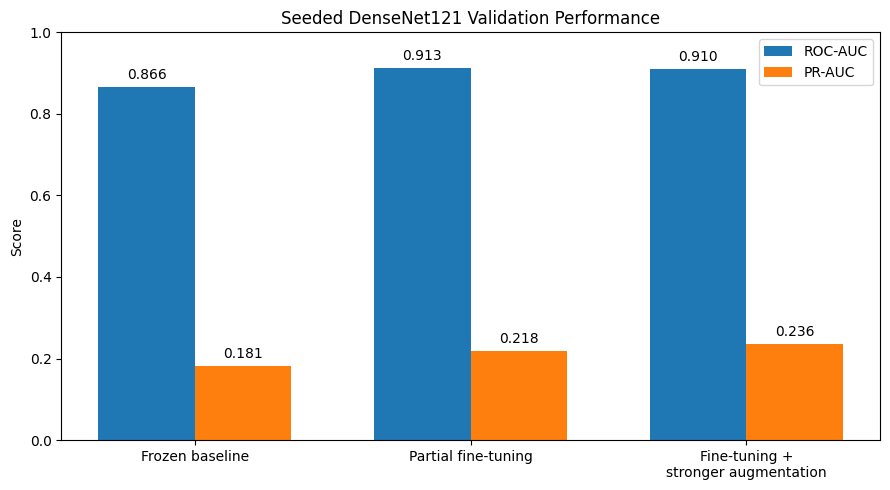

In [1]:
# ============================================================
# VISUAL 1: Seeded DenseNet121 experiment comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

experiment_names = [
    "Frozen baseline",
    "Partial fine-tuning",
    "Fine-tuning +\nstronger augmentation"
]

roc_auc_scores = [
    0.866,
    0.913,
    0.910
]

pr_auc_scores = [
    0.181,
    0.218,
    0.236
]

x = np.arange(len(experiment_names))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    roc_auc_scores,
    width,
    label="ROC-AUC"
)

plt.bar(
    x + width/2,
    pr_auc_scores,
    width,
    label="PR-AUC"
)

plt.xticks(
    x,
    experiment_names
)

plt.ylabel("Score")
plt.ylim(0, 1)

plt.title(
    "Seeded DenseNet121 Validation Performance"
)

plt.legend()

for i, value in enumerate(roc_auc_scores):
    plt.text(
        i - width/2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

for i, value in enumerate(pr_auc_scores):
    plt.text(
        i + width/2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()